In [8]:
import pandas as pd
# importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv('Iris.csv', sep=',', index_col=None)

# exibe o dataframe
df_dataset.head(10)

,Id,Sepal_Length_Cm,Sepal_Width_Cm,Petal_Length_Cm,Petal_Width_Cm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Suponha que você tenha seus dados X e os rótulos y
X = df_dataset[["Sepal_Length_Cm", "Sepal_Width_Cm", "Petal_Length_Cm",	"Petal_Width_Cm"]]
y = df_dataset['Species']

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Crie um modelo KNN com um certo número de vizinhos (n_neighbors)
knn_model = KNeighborsClassifier(n_neighbors=3)

# Treine o modelo com os dados de treinamento
knn_model.fit(X_train, y_train)

# Faça previsões com o modelo nos dados de teste
y_pred = knn_model.predict(X_test)

# Calcule a acurácia das previsões
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)


Acurácia: 0.9777777777777777


In [12]:
df_teste = X_test
df_teste["y_test"] = y_test
df_teste["y_pred"] =  y_pred
df_teste

,Sepal_Length_Cm,Sepal_Width_Cm,Petal_Length_Cm,Petal_Width_Cm,y_test,y_pred
14,5.8,4.0,1.2,0.2,Iris-setosa,Iris-setosa
98,5.1,2.5,3.0,1.1,Iris-versicolor,Iris-versicolor
75,6.6,3.0,4.4,1.4,Iris-versicolor,Iris-versicolor
16,5.4,3.9,1.3,0.4,Iris-setosa,Iris-setosa
131,7.9,3.8,6.4,2.0,Iris-virginica,Iris-virginica
56,6.3,3.3,4.7,1.6,Iris-versicolor,Iris-versicolor
141,6.9,3.1,5.1,2.3,Iris-virginica,Iris-virginica
44,5.1,3.8,1.9,0.4,Iris-setosa,Iris-setosa
29,4.7,3.2,1.6,0.2,Iris-setosa,Iris-setosa
120,6.9,3.2,5.7,2.3,Iris-virginica,Iris-virginica


Melhor valor de k: 7
Acurácia no conjunto de teste: 0.9777777777777777


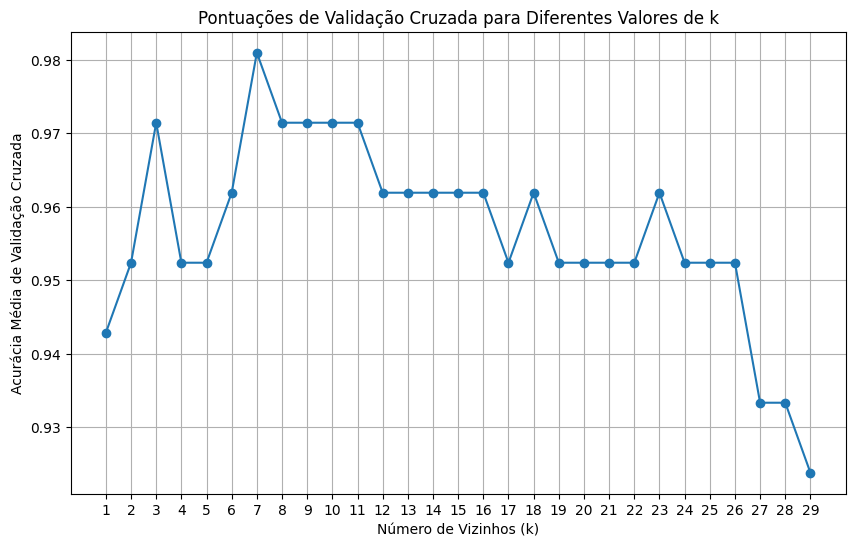

In [13]:
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Suponha que você tenha seus dados X e os rótulos y

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

# Crie uma lista de valores de k para testar
k_values = list(range(1, 30))

# Inicialize uma lista para armazenar as pontuações de validação cruzada
cross_val_scores = []

# Teste diferentes valores de k usando validação cruzada
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_model, X_train, y_train, cv=5)  # 5-fold cross-validation
    cross_val_scores.append(np.mean(scores))

# Encontre o valor de k com a melhor pontuação média de validação cruzada
best_k = k_values[np.argmax(cross_val_scores)]
print("Melhor valor de k:", best_k)

# Treine o modelo com o melhor valor de k usando todos os dados de treinamento
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train, y_train)

# Avalie o modelo nos dados de teste
accuracy = best_knn_model.score(X_test, y_test)
print("Acurácia no conjunto de teste:", accuracy)


# Plote os resultados da validação cruzada em um gráfico
plt.figure(figsize=(10, 6))
plt.plot(k_values, cross_val_scores, marker='o')
plt.title('Pontuações de Validação Cruzada para Diferentes Valores de k')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia Média de Validação Cruzada')
plt.xticks(k_values)
plt.grid(True)
plt.show()

